There are now three version of the code:

1. The original Barnes2020-FillSpillMerge
This does not include saving and reloading the depression hierachy.

2. Kerry's version of Barnes2020-FillSpillMerge
this includes saving of the DH

3. Richdem 
This now includes FSM and the loading reloading of the DH. 

Below I am trying to document which versions compile, with what errors and how each runs. 

Table:
| Version | Compile command | Compiles? | Runs with swl? | Runs with swf? | 
| --- | --- | --- | --- | --- |
| Original Barnes2020-FillSpillMerge | `cmake -DCMAKE_BUILD_TYPE=Release -D CMAKE_C_COMPILER="/opt/homebrew/Cellar/llvm/18.1.5/bin/clang" -D CMAKE_CXX_COMPILER="/opt/homebrew/Cellar/llvm/18.1.5/bin/clang++"  -DUSE_GDAL=ON ..` | yes | no georeference info in results |  no georeference info in results |
| old build of Barnes2020-FillSpillMerge | `cmake -D CMAKE_C_COMPILER="/opt/homebrew/Cellar/llvm/17.0.6/bin/clang" -D CMAKE_CXX_COMPILER="/opt/homebrew/Cellar/llvm/17.0.6/bin/clang++" -DUSE_GDAL=ON  -DCMAKE_BUILD_TYPE=Release ..` | yes | yes |  yes |
| Kerry's version of Barnes2020-FillSpillMerge | `cmake -DCMAKE_C_COMPILER="/opt/homebrew/Cellar/llvm/18.1.5/bin/clang" -D CMAKE_CXX_COMPILER="/opt/homebrew/Cellar/llvm/18.1.5/bin/clang++" -DUSE_GDAL=ON  -DCMAKE_BUILD_TYPE=Release -DCMAKE_BUILD_TYPE=Release -DUSE_BOOST=ON -DBOOST_ROOT=/opt/homebrew/Cellar/boost/1.85.0 ..` | yes, with warnings that havent caused an issue in the past |  no georeference info in results |  no georeference info in results |
| Richdem | `cmake -DCMAKE_C_COMPILER="/opt/homebrew/Cellar/llvm/18.1.5/bin/clang" -D CMAKE_CXX_COMPILER="/opt/homebrew/Cellar/llvm/18.1.5/bin/clang++" -DUSE_GDAL=ON  -DCMAKE_BUILD_TYPE=Release -DCMAKE_BUILD_TYPE=Release -DBOOST_ROOT=/opt/homebrew/Cellar/boost/1.85.0 ..` | yes, if you use `make -j 10` to compile fsm before the process failes on tests.cpp | no georeference info in results | no georeference info in results |

The details of each error are summarized below. 

The one workgin version I have is contained in /Users/jkingslake/Documents/science/meltwater_routing/main_fork_of_FSM_repo/Barnes2020-FillSpillMerge/build_old
Its strange because I compiled this using the same command that now creates a non-working version from the same repo. The only difference is the version of the compliers has been updated. 

In [20]:
import subprocess
import rioxarray


In [6]:
repo_directories = ['/Users/jkingslake/Documents/science/meltwater_routing/main_fork_of_FSM_repo/Barnes2020-FillSpillMerge',
'/Users/jkingslake/Documents/science/meltwater_routing/kerrys_fork_of_FSM/Barnes2020-FillSpillMerge','/Users/jkingslake/Documents/science/meltwater_routing/richdem']

## Original Barnes2020-FillSpillMerge

Compiles succesfully with
```
cmake -DCMAKE_BUILD_TYPE=Release -D CMAKE_C_COMPILER="/opt/homebrew/Cellar/llvm/18.1.5/bin/clang" -D CMAKE_CXX_COMPILER="/opt/homebrew/Cellar/llvm/18.1.5/bin/clang++"  -DUSE_GDAL=ON ..

make
```

then run `--swl`  verion with 
```
./fsm.exe /Users/jkingslake/Documents/science/meltwater_routing/BFRN_meltwater/python/notebooks/rema_subsets/dem_small_2.tif test 0.0
```
and you get an error: `ERROR 1: GetNoDataValue() should be called instead` displayed after `m Ocean level         = 0`

And the resulting geotiff has no georeferencing information:

In [26]:
water_depth = rioxarray.open_rasterio(repo_directories[0] + "/build/test-wtd.tif").squeeze()

/Users/jkingslake/miniconda3/envs/full_py_env/lib/python3.11/site-packages/rioxarray/_io.py:1132: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  warnings.warn(str(rio_warning.message), type(rio_warning.message))  # type: ignore


it also creates a file called 'dem_small_2.tif.aux.xml' which you need to delete before you can try loading hte dem again for the next test. If you do not delete this file first, the dem is loaded with zeros for x and y. 

Create a melt file with



In [36]:
dem = rioxarray.open_rasterio('/Users/jkingslake/Documents/science/meltwater_routing/BFRN_meltwater/python/notebooks/rema_subsets/dem_small_2.tif')

dem = dem.squeeze() 
melt = dem.copy().squeeze()
melt[:, :] = 0
melt.loc[1.935e6:1.93e6, 815000:820000] = 0.2  # ymin and ymax are flipped because the y-axis is flipped
melt.rio.to_raster('melt_temp.tif')



Run the `--swf` version with 
``` 
./fsm.exe /Users/jkingslake/Documents/science/meltwater_routing/BFRN_meltwater/python/notebooks/rema_subsets/dem_small_2.tif test 0.0 --swf=/Users/jkingslake/Documents/science/meltwater_routing/BFRN_meltwater/python/fsm_version_testing/melt_temp.tif
```

This results in a number of warnings
```
m Input DEM           = /Users/jkingslake/Documents/science/meltwater_routing/BFRN_meltwater/python/notebooks/rema_subsets/dem_small_2.tif
m Output prefix       = test
m Surface water level = nan
m Surface water file  = /Users/jkingslake/Documents/science/meltwater_routing/BFRN_meltwater/python/fsm_version_testing/melt_temp.tif
m Ocean level         = 0
ERROR 1: GetNoDataValue() should be called instead
m Data width  = 1024
m Data height = 3072
m Data cells  = 3145728
ERROR 1: GetNoDataValue() should be called instead
ERROR 6: test-wtd.tif: Dataset does not support the AddBand() method.
ERROR 6: test-hydrologic-surface-height.tif: Dataset does not support the AddBand() method.
Finished.
IO time   = 0.0536605 s
Calc time = 1.88421 s
```



and the xml file is created again, and the resulting geotiff has no georeferencing information.

In [50]:
water_depth = rioxarray.open_rasterio(repo_directories[0] + "/build/test-wtd.tif").squeeze()


/Users/jkingslake/miniconda3/envs/full_py_env/lib/python3.11/site-packages/rioxarray/_io.py:1132: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  warnings.warn(str(rio_warning.message), type(rio_warning.message))  # type: ignore


In [49]:
# double check that the old build still works by running the same command in build_old in the terminal...
# It gives what we expect, a georeferenced geotiff

water_depth = rioxarray.open_rasterio(repo_directories[0] + "/build_old/test-wtd.tif").squeeze()
water_depth

<xarray.DataArray (y: 3072, x: 1024)>
[3145728 values with dtype=float64]
Coordinates:
    band         int64 1
  * x            (x) float64 8e+05 8e+05 8.001e+05 ... 8.327e+05 8.327e+05
  * y            (y) float64 2e+06 2e+06 2e+06 ... 1.902e+06 1.902e+06 1.902e+06
    spatial_ref  int64 0
Attributes:
    AREA_OR_POINT:       Area
    PROCESSING_HISTORY:  2024-05-25 18:47:54 UTC | RichDEM v2.2.9 (hash=41503...
    TIFFTAG_DATETIME:    2024-05-25 18:47:54 UTC
    TIFFTAG_SOFTWARE:    RichDEM v2.2.9 (hash=415032db2f303721, compiled=2024...
    _FillValue:          -9999.0
    scale_factor:        1.0
    add_offset:          0.0

## Kerry's version of Barnes2020-FillSpillMerge

Complises succesfully with 
```
cmake -DCMAKE_C_COMPILER="/opt/homebrew/Cellar/llvm/18.1.5/bin/clang" -D CMAKE_CXX_COMPILER="/opt/homebrew/Cellar/llvm/18.1.5/bin/clang++" -DUSE_GDAL=ON  -DCMAKE_BUILD_TYPE=Release -DCMAKE_BUILD_TYPE=Release -DUSE_BOOST=ON -DBOOST_ROOT=/opt/homebrew/Cellar/boost/1.85.0 ..

make
```
but raises a few warnings about depreciated functions (sprintf).

Then run the `--swl` version with 
```
./fsm_boost.exe /Users/jkingslake/Documents/science/meltwater_routing/BFRN_meltwater/python/notebooks/rema_subsets/dem_small_2.tif test 0.0 --swl=0.1 --save_dh dh_stored_filename
```

This raises the same errors as above:
```
m Input DEM           = /Users/jkingslake/Documents/science/meltwater_routing/BFRN_meltwater/python/notebooks/rema_subsets/dem_small_2.tif
m Output prefix       = test
m Surface water level = nan
m Surface water file  = 
m Ocean level         = 0
m Filename to save DH for reuse         = dh_stored_filename
m Filename to open previously saved DH  = 
ERROR 1: GetNoDataValue() should be called instead
m Data width  = 1024
m Data height = 3072
m Data cells  = 3145728
ERROR 1: GetNoDataValue() should be called instead
Array saved to file successfully.
ERROR 6: test-wtd.tif: Dataset does not support the AddBand() method.
ERROR 6: test-hydrologic-surface-height.tif: Dataset does not support the AddBand() method.
Finished.
IO time   = 0.0655622 s
Calc time = 2.15986 s
```


The results is a wtd geotiff that does not contain georeferencing information.

/Users/jkingslake/miniconda3/envs/full_py_env/lib/python3.11/site-packages/rioxarray/_io.py:1132: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  warnings.warn(str(rio_warning.message), type(rio_warning.message))  # type: ignore


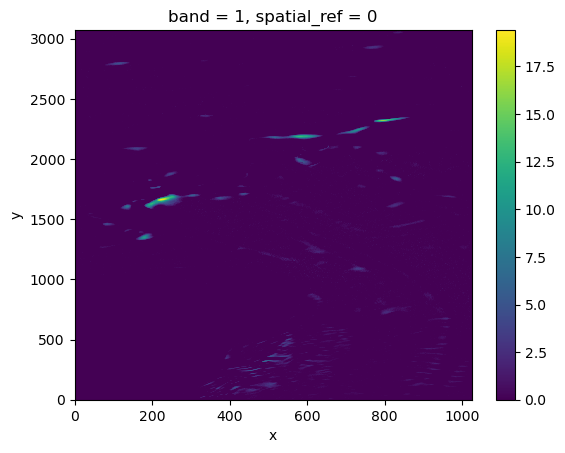

In [62]:
water_depth = rioxarray.open_rasterio(repo_directories[1] + "/build/test-wtd.tif").squeeze()
water_depth.plot()


Run the `--swf` version with 
```
./fsm_boost.exe /Users/jkingslake/Documents/science/meltwater_routing/BFRN_meltwater/python/notebooks/rema_subsets/dem_small_2.tif test 0.0 --swf=/Users/jkingslake/Documents/science/meltwater_routing/BFRN_meltwater/python/fsm_version_testing/melt_temp.tif --save_dh dh_stored_filename
```

This leads to the same issue with georeferencing as above

/Users/jkingslake/miniconda3/envs/full_py_env/lib/python3.11/site-packages/rioxarray/_io.py:1132: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  warnings.warn(str(rio_warning.message), type(rio_warning.message))  # type: ignore


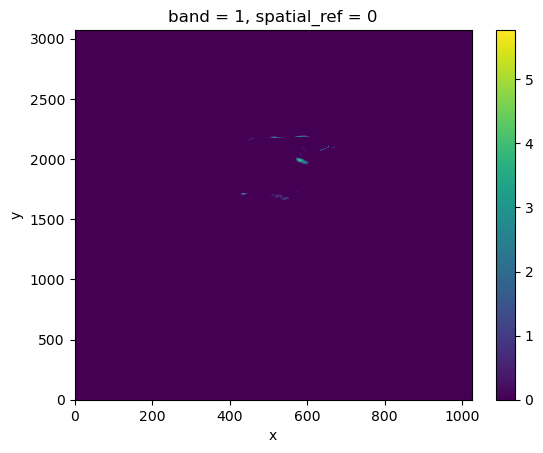

In [60]:
water_depth = rioxarray.open_rasterio(repo_directories[1] + "/build/test-wtd.tif").squeeze()
water_depth.plot()


## Richdem version

Compile with
```
cmake -DCMAKE_C_COMPILER="/opt/homebrew/Cellar/llvm/18.1.5/bin/clang" -D CMAKE_CXX_COMPILER="/opt/homebrew/Cellar/llvm/18.1.5/bin/clang++" -DUSE_GDAL=ON  -DCMAKE_BUILD_TYPE=Release -DCMAKE_BUILD_TYPE=Release -DBOOST_ROOT=/opt/homebrew/Cellar/boost/1.85.0 ..

make
```

it fails with errors:
```
[  1%] Building CXX object CMakeFiles/richdem.dir/src/richdem.cpp.o
[  2%] Building CXX object CMakeFiles/richdem.dir/src/random.cpp.o
[  4%] Building CXX object CMakeFiles/richdem.dir/src/gdal.cpp.o
[  5%] Building CXX object CMakeFiles/richdem.dir/src/terrain_generation/terrain_generation.cpp.o
[  7%] Building CXX object CMakeFiles/richdem.dir/src/terrain_generation/PerlinNoise.cpp.o
[  8%] Linking CXX shared library librichdem.dylib
[  8%] Built target richdem
[ 10%] Building CXX object CMakeFiles/richdem_unittests.dir/tests/tests.cpp.o
In file included from /Users/jkingslake/Documents/science/meltwater_routing/richdem/tests/tests.cpp:7:
In file included from /Users/jkingslake/Documents/science/meltwater_routing/richdem/include/richdem/richdem.hpp:7:
/Users/jkingslake/Documents/science/meltwater_routing/richdem/include/richdem/common/memory.hpp:52:13: warning: Cannot check memory statistics for this OS. [-W#pragma-messages]
   52 |     #pragma message("Cannot check memory statistics for this OS.")
      |             ^
/Users/jkingslake/Documents/science/meltwater_routing/richdem/tests/tests.cpp:71:16: warning: captured structured bindings are a C++20 extension [-Wc++20-extensions]
   71 |       REQUIRE( x==0 );
      |                ^
/Users/jkingslake/Documents/science/meltwater_routing/richdem/tests/tests.cpp:70:19: note: 'x' declared here
   70 |       const auto [x, y] = arr.iToxy(0);
      |                   ^
/Users/jkingslake/Documents/science/meltwater_routing/richdem/tests/tests.cpp:71:16: error: capturing a structured binding is not yet supported in OpenMP
   71 |       REQUIRE( x==0 );
      |                ^
/Users/jkingslake/Documents/science/meltwater_routing/richdem/tests/tests.cpp:70:19: note: 'x' declared here
   70 |       const auto [x, y] = arr.iToxy(0);
      |                   ^
/Users/jkingslake/Documents/science/meltwater_routing/richdem/tests/tests.cpp:72:16: warning: captured structured bindings are a C++20 extension [-Wc++20-extensions]
   72 |       REQUIRE( y==0 );
      |                ^
/Users/jkingslake/Documents/science/meltwater_routing/richdem/tests/tests.cpp:70:22: note: 'y' declared here
   70 |       const auto [x, y] = arr.iToxy(0);
      |                      ^
/Users/jkingslake/Documents/science/meltwater_routing/richdem/tests/tests.cpp:72:16: error: capturing a structured binding is not yet supported in OpenMP
   72 |       REQUIRE( y==0 );
      |                ^
/Users/jkingslake/Documents/science/meltwater_routing/richdem/tests/tests.cpp:70:22: note: 'y' declared here
   70 |       const auto [x, y] = arr.iToxy(0);
      |                      ^
/Users/jkingslake/Documents/science/meltwater_routing/richdem/tests/tests.cpp:77:16: warning: captured structured bindings are a C++20 extension [-Wc++20-extensions]
   77 |       REQUIRE( x==arr.width()-1  );
      |                ^
/Users/jkingslake/Documents/science/meltwater_routing/richdem/tests/tests.cpp:76:19: note: 'x' declared here
   76 |       const auto [x,y] = arr.iToxy(arr.size()-1);
      |                   ^
/Users/jkingslake/Documents/science/meltwater_routing/richdem/tests/tests.cpp:77:16: error: capturing a structured binding is not yet supported in OpenMP
   77 |       REQUIRE( x==arr.width()-1  );
      |                ^
/Users/jkingslake/Documents/science/meltwater_routing/richdem/tests/tests.cpp:76:19: note: 'x' declared here
   76 |       const auto [x,y] = arr.iToxy(arr.size()-1);
      |                   ^
/Users/jkingslake/Documents/science/meltwater_routing/richdem/tests/tests.cpp:78:16: warning: captured structured bindings are a C++20 extension [-Wc++20-extensions]
   78 |       REQUIRE( y==arr.height()-1 );
      |                ^
/Users/jkingslake/Documents/science/meltwater_routing/richdem/tests/tests.cpp:76:21: note: 'y' declared here
   76 |       const auto [x,y] = arr.iToxy(arr.size()-1);
      |                     ^
/Users/jkingslake/Documents/science/meltwater_routing/richdem/tests/tests.cpp:78:16: error: capturing a structured binding is not yet supported in OpenMP
   78 |       REQUIRE( y==arr.height()-1 );
      |                ^
/Users/jkingslake/Documents/science/meltwater_routing/richdem/tests/tests.cpp:76:21: note: 'y' declared here
   76 |       const auto [x,y] = arr.iToxy(arr.size()-1);
      |                     ^
5 warnings and 4 errors generated.
make[2]: *** [CMakeFiles/richdem_unittests.dir/tests/tests.cpp.o] Error 1
make[1]: *** [CMakeFiles/richdem_unittests.dir/all] Error 2
make: *** [all] Error 2
```



If you run 
```
make -j 10
```
it manages to get to the fill-spill-merge compile before it fails on test.cpp as seen in the errors above. 

Now we run the `--swl` version with 
``` 
apps/rd_fill_spill_merge.exe  /Users/jkingslake/Documents/science/meltwater_routing/BFRN_meltwater/python/notebooks/rema_subsets/dem_small_2.tif test 0 --swl 0.1  --save_dh  my_DH
```

This causes the same error as above with the lack of gepreferencing in the result
```
m Input DEM           = /Users/jkingslake/Documents/science/meltwater_routing/BFRN_meltwater/python/notebooks/rema_subsets/dem_small_2.tif
m Output prefix       = test
m Surface water level = 0.1
m Surface water file  = 
m Ocean level         = 0
p Reading topography...
ERROR 1: GetNoDataValue() should be called instead
m Data width  = 1024
m Data height = 3072
m Data cells  = 3145728
p Performing bucket fill...
p Getting depression hierarchy...
m Saving DH to my_DH
p Performing FillSpillMerge...
ERROR 6: test-wtd.tif: Dataset does not support the AddBand() method.
ERROR 6: test-hydrologic-surface-height.tif: Dataset does not support the AddBand() method.
Finished.
IO time   = 0.056188 s
Calc time = 0.68416 s
```

In [67]:
water_depth = rioxarray.open_rasterio(repo_directories[2] + "/build/test-wtd.tif").squeeze()
water_depth


/Users/jkingslake/miniconda3/envs/full_py_env/lib/python3.11/site-packages/rioxarray/_io.py:1132: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  warnings.warn(str(rio_warning.message), type(rio_warning.message))  # type: ignore


<xarray.DataArray (y: 3072, x: 1024)>
[3145728 values with dtype=float64]
Coordinates:
    band         int64 1
  * x            (x) float64 0.5 1.5 2.5 3.5 ... 1.022e+03 1.022e+03 1.024e+03
  * y            (y) float64 0.5 1.5 2.5 3.5 ... 3.07e+03 3.07e+03 3.072e+03
    spatial_ref  int64 0
Attributes:
    AREA_OR_POINT:       Area
    PROCESSING_HISTORY:  2024-05-30 19:10:07 UTC | RichDEM v2.2.9 (hash=eb7ba...
    TIFFTAG_DATETIME:    2024-05-30 19:10:07 UTC
    TIFFTAG_SOFTWARE:    RichDEM v2.2.9 (hash=eb7bac6e12efa750, compiled=2024...
    _FillValue:          1.0
    scale_factor:        1.0
    add_offset:          0.0

Run the `--swf` version with 
```
apps/rd_fill_spill_merge.exe  /Users/jkingslake/Documents/science/meltwater_routing/BFRN_meltwater/python/notebooks/rema_subsets/dem_small_2.tif test 0 --swf=/Users/jkingslake/Documents/science/meltwater_routing/BFRN_meltwater/python/fsm_version_testing/melt_temp.tif  --save_dh  my_DH
```

with the same results


/Users/jkingslake/miniconda3/envs/full_py_env/lib/python3.11/site-packages/rioxarray/_io.py:1132: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  warnings.warn(str(rio_warning.message), type(rio_warning.message))  # type: ignore


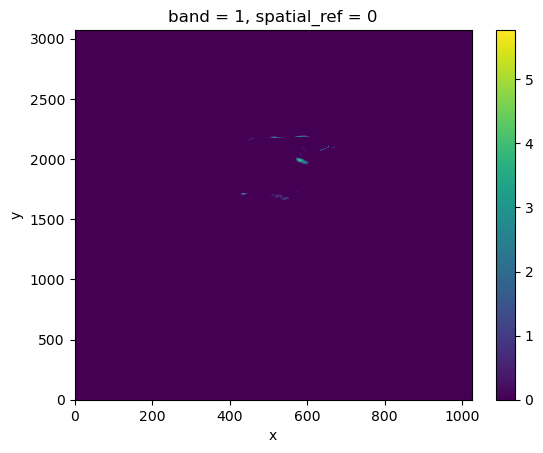

In [66]:
water_depth = rioxarray.open_rasterio(repo_directories[2] + "/build/test-wtd.tif").squeeze()
water_depth.plot()
